In [16]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\gears\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
import pandas as pd

# 1. Cargar el dataset (Ruta corregida a la raíz del proyecto)
df = pd.read_csv('titanic.csv') 

# 2. Definir X con las características seleccionadas
X = df[['Age', 'Fare', 'Pclass']].copy()

# 3. Imputación de valores faltantes (Requisito para KMeans)
X['Age'] = X['Age'].fillna(X['Age'].median())
X['Fare'] = X['Fare'].fillna(X['Fare'].median())

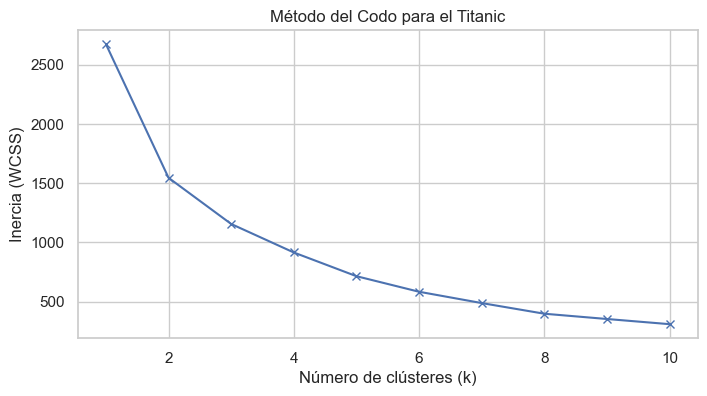

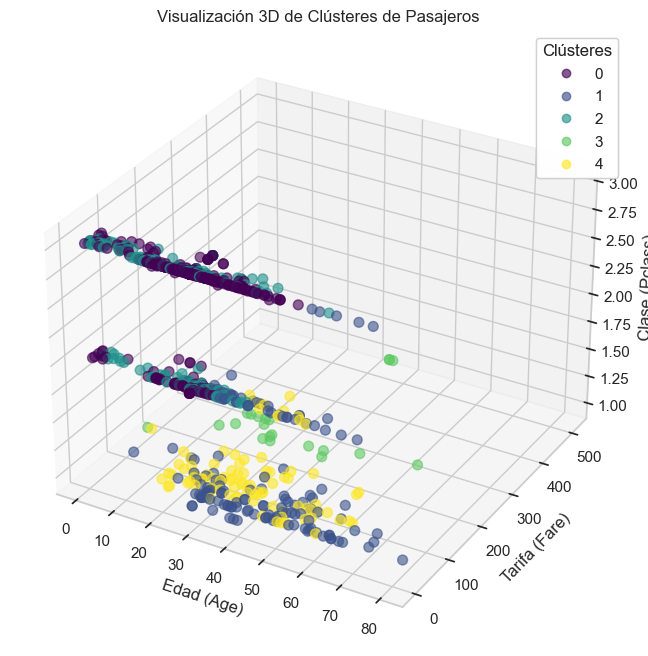


ANÁLISIS DE CLÚSTERES (PERFILES MEDIOS):
Cluster 0:
 - Género predominante (0=M, 1=F): 0.00
 - Edad media: 25.67 años
 - Tarifa media (Fare): $13.82
 - Clase media (Pclass): 2.84
Cluster 1:
 - Género predominante (0=M, 1=F): 0.00
 - Edad media: 41.60 años
 - Tarifa media (Fare): $40.50
 - Clase media (Pclass): 1.32
Cluster 2:
 - Género predominante (0=M, 1=F): 1.00
 - Edad media: 24.02 años
 - Tarifa media (Fare): $17.78
 - Clase media (Pclass): 2.69
Cluster 3:
 - Género predominante (0=M, 1=F): 0.57
 - Edad media: 29.42 años
 - Tarifa media (Fare): $273.22
 - Clase media (Pclass): 1.00
Cluster 4:
 - Género predominante (0=M, 1=F): 1.00
 - Edad media: 36.36 años
 - Tarifa media (Fare): $75.97
 - Clase media (Pclass): 1.13


In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans 
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 1. CARGA Y LIMPIEZA (Paso crítico inicial)
# ==========================================
df = pd.read_csv('titanic.csv')

# Imputar valores faltantes antes de cualquier cálculo
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Mapeo de género
df['Sex_Numeric'] = df['Sex'].map({'male': 0, 'female': 1})

# Definir el DataFrame de trabajo X con las variables base
X = df[['Age', 'Fare', 'Pclass', 'Sex_Numeric']].copy()

# ==========================================
# 2. ESCALAMIENTO Y DIAGNÓSTICO
# ==========================================
scaler_clustering = StandardScaler()
# Usamos las 3 variables originales para el diagnóstico del codo
X_scaled_base = scaler_clustering.fit_transform(X[['Age', 'Fare', 'Pclass']])

inercias = []
K = range(1, 11)

for k in K:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_scaled_base)
    inercias.append(kmeans_test.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inercias, 'bx-')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Inercia (WCSS)')
plt.title('Método del Codo para el Titanic')
plt.show()

# ==========================================
# 3. K-MEANS EXTENDIDO (Incluyendo Género)
# ==========================================
# Seleccionamos las 4 variables para el modelo final (k=5 según requerimiento)
extended_features = X[['Sex_Numeric', 'Age', 'Fare', 'Pclass']]
scaled_features = scaler_clustering.fit_transform(extended_features)

kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
X['Cluster_Label'] = kmeans.fit_predict(scaled_features)

# ==========================================
# 4. VISUALIZACIÓN 3D
# ==========================================
sns.set(style="whitegrid")
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Mapeo de datos (Usamos Cluster_Label para el color)
scatter = ax.scatter(X['Age'], X['Fare'], X['Pclass'],
                     c=X['Cluster_Label'], 
                     cmap='viridis', s=50, alpha=0.6)

ax.set_xlabel('Edad (Age)')
ax.set_ylabel('Tarifa (Fare)')
ax.set_zlabel('Clase (Pclass)')
ax.set_title('Visualización 3D de Clústeres de Pasajeros')

legend1 = ax.legend(*scatter.legend_elements(), title="Clústeres")
ax.add_artist(legend1)
plt.show()

# ==========================================
# 5. ANÁLISIS DE PERFILES Y RECOMENDACIONES
# ==========================================
# Agrupación por clúster para obtener promedios
cluster_analysis = X.groupby('Cluster_Label').mean()

print("\nANÁLISIS DE CLÚSTERES (PERFILES MEDIOS):")
print("===========================================")
for cluster in cluster_analysis.index:
    print(f"Cluster {cluster}:")
    print(f" - Género predominante (0=M, 1=F): {cluster_analysis['Sex_Numeric'][cluster]:.2f}")
    print(f" - Edad media: {cluster_analysis['Age'][cluster]:.2f} años")
    print(f" - Tarifa media (Fare): ${cluster_analysis['Fare'][cluster]:.2f}")
    print(f" - Clase media (Pclass): {cluster_analysis['Pclass'][cluster]:.2f}")
    print("===========================================")